# Customer Churn Prediction

This notebook builds an end-to-end churn prediction workflow on the Telco Customer Churn dataset, covering data understanding, exploratory analysis, feature engineering, Decision Tree modeling, evaluation, interpretation, model saving, and API artifacts.

## Section 1 - Data Understanding and Preparation

This section loads the Telco Customer Churn dataset and the supporting data dictionary, checks the structure and quality of the data, documents preprocessing decisions, and creates a leakage-safe train/test split using `random_state=42` and a 70:30 ratio.

In [17]:
import io
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TEST_SIZE = 0.30
BASE_DIR = Path("../nagp_ml").resolve()
DATA_PATH = BASE_DIR / "data" / "TelcoCustomerChurn.csv"
DICTIONARY_PATH = BASE_DIR / "data" / "DataDictionary.csv"
MODEL_DIR = BASE_DIR / "model"
MODEL_PATH = MODEL_DIR / "churn_model.pkl"

RAW_FEATURE_COLUMNS = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "tenure", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "MonthlyCharges", "TotalCharges"
]

SERVICE_COLUMNS = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

NUMERIC_FEATURES = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
    "avg_monthly_charge", "service_count"
]

CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "tenure_group"
]


def create_feature_table(df_input: pd.DataFrame) -> pd.DataFrame:
    df_out = df_input.copy()
    df_out["TotalCharges"] = pd.to_numeric(
        df_out["TotalCharges"].replace(" ", np.nan), errors="coerce"
    )
    df_out["TotalCharges"] = df_out["TotalCharges"].fillna(0)
    df_out["SeniorCitizen"] = df_out["SeniorCitizen"].astype(int)

    df_out["tenure_group"] = pd.cut(
        df_out["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    ).astype(str)

    df_out["avg_monthly_charge"] = np.where(
        df_out["tenure"] > 0,
        df_out["TotalCharges"] / df_out["tenure"],
        df_out["MonthlyCharges"],
    )

    df_out["service_count"] = (
        (df_out["PhoneService"] == "Yes").astype(int)
        + (df_out["MultipleLines"] == "Yes").astype(int)
        + (df_out["OnlineSecurity"] == "Yes").astype(int)
        + (df_out["OnlineBackup"] == "Yes").astype(int)
        + (df_out["DeviceProtection"] == "Yes").astype(int)
        + (df_out["TechSupport"] == "Yes").astype(int)
        + (df_out["StreamingTV"] == "Yes").astype(int)
        + (df_out["StreamingMovies"] == "Yes").astype(int)
    )
    return df_out


def build_pipeline(max_depth=None, criterion="gini"):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                ]),
                NUMERIC_FEATURES,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ]
    )

    pipeline = Pipeline([
        ("feature_builder", FunctionTransformer(create_feature_table, validate=False)),
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                max_depth=max_depth,
                criterion=criterion,
            ),
        ),
    ])
    return pipeline


print(f"Dataset path: {DATA_PATH}")
print(f"Data dictionary path: {DICTIONARY_PATH}")
print(f"Model output path: {MODEL_PATH}")

Dataset path: C:\Users\chagantychaitanya\Downloads\nagp_ml\data\TelcoCustomerChurn.csv
Data dictionary path: C:\Users\chagantychaitanya\Downloads\nagp_ml\data\DataDictionary.csv
Model output path: C:\Users\chagantychaitanya\Downloads\nagp_ml\model\churn_model.pkl


In [18]:
data_dictionary = pd.read_csv(DICTIONARY_PATH)
raw_df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {raw_df.shape}")
print(f"Data dictionary shape: {data_dictionary.shape}")

display(raw_df.head())
display(data_dictionary.head())

info_buffer = io.StringIO()
raw_df.info(buf=info_buffer)
print(info_buffer.getvalue())

display(raw_df.describe(include="all").transpose())

analysis_df = raw_df.copy()
analysis_df["TotalCharges"] = pd.to_numeric(
    analysis_df["TotalCharges"].replace(" ", np.nan), errors="coerce"
)

missing_summary = pd.DataFrame({
    "raw_missing": raw_df.isna().sum(),
    "missing_after_totalcharges_numeric": analysis_df.isna().sum(),
})
display(missing_summary)

blank_totalcharges_rows = raw_df.loc[
    analysis_df["TotalCharges"].isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"],
]
display(blank_totalcharges_rows)

print(f"Duplicate rows: {raw_df.duplicated().sum()}")

feature_type_summary = pd.DataFrame({
    "feature": analysis_df.columns,
    "analytical_type": [
        "target" if col == "Churn" else
        "identifier" if col == "customerID" else
        "numerical" if pd.api.types.is_numeric_dtype(analysis_df[col]) else
        "categorical"
        for col in analysis_df.columns
    ],
    "dtype": [str(analysis_df[col].dtype) for col in analysis_df.columns],
})
display(feature_type_summary)

churn_summary = raw_df["Churn"].value_counts().rename_axis("Churn").reset_index(name="count")
churn_summary["percentage"] = (churn_summary["count"] / len(raw_df) * 100).round(2)
display(churn_summary)

X_raw = raw_df[RAW_FEATURE_COLUMNS].copy()
y = raw_df["Churn"].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")
print("Train churn rate:", round((y_train == "Yes").mean(), 4))
print("Test churn rate:", round((y_test == "Yes").mean(), 4))

preprocessing_notes = [
    "customerID is excluded from modeling because it is only an identifier.",
    "TotalCharges contains 11 blank-string records. They correspond to tenure=0 customers and are converted to numeric with blanks filled as 0.",
    "The target Churn remains Yes/No rather than being label-encoded because sklearn can train directly on string labels.",
    "The train/test split is created before fitting any imputers or encoders to avoid data leakage.",
    "All feature engineering, imputing, and one-hot encoding are encapsulated inside the modeling pipeline so train and inference logic stay consistent.",
]

print("\nPreprocessing decisions:")
for idx, note in enumerate(preprocessing_notes, start=1):
    print(f"{idx}. {note}")

Dataset shape: (7043, 21)
Data dictionary shape: (21, 4)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


Duplicate rows: 0


,feature,analytical_type,dtype
0,customerID,identifier,str
1,gender,categorical,str
2,SeniorCitizen,numerical,int64
3,Partner,categorical,str
4,Dependents,categorical,str
5,tenure,numerical,int64
6,PhoneService,categorical,str
7,MultipleLines,categorical,str
8,InternetService,categorical,str
9,OnlineSecurity,categorical,str


,Churn,count,percentage
0,No,5174,73.46
1,Yes,1869,26.54


Train shape: (4930, 19), Test shape: (2113, 19)
Train churn rate: 0.2653
Test churn rate: 0.2655

Preprocessing decisions:
1. customerID is excluded from modeling because it is only an identifier.
2. TotalCharges contains 11 blank-string records. They correspond to tenure=0 customers and are converted to numeric with blanks filled as 0.
3. The target Churn remains Yes/No rather than being label-encoded because sklearn can train directly on string labels.
4. The train/test split is created before fitting any imputers or encoders to avoid data leakage.
5. All feature engineering, imputing, and one-hot encoding are encapsulated inside the modeling pipeline so train and inference logic stay consistent.


### Section 1 observations

* The dataset contains 7,043 customer records and 21 columns, which is adequate for a first-pass churn classification model.
* `TotalCharges` is stored as text because 11 records contain blank spaces. These rows belong to customers with `tenure = 0`, so replacing the blank with `0` is a defensible business rule for newly onboarded customers.
* The target variable is imbalanced toward `No`, so evaluation should go beyond accuracy and include precision, recall, and F1 score.
* To avoid data leakage, the split is done before fitting transformations, and preprocessing is kept inside the model pipeline.

## Section 2 - Exploratory Data Analysis


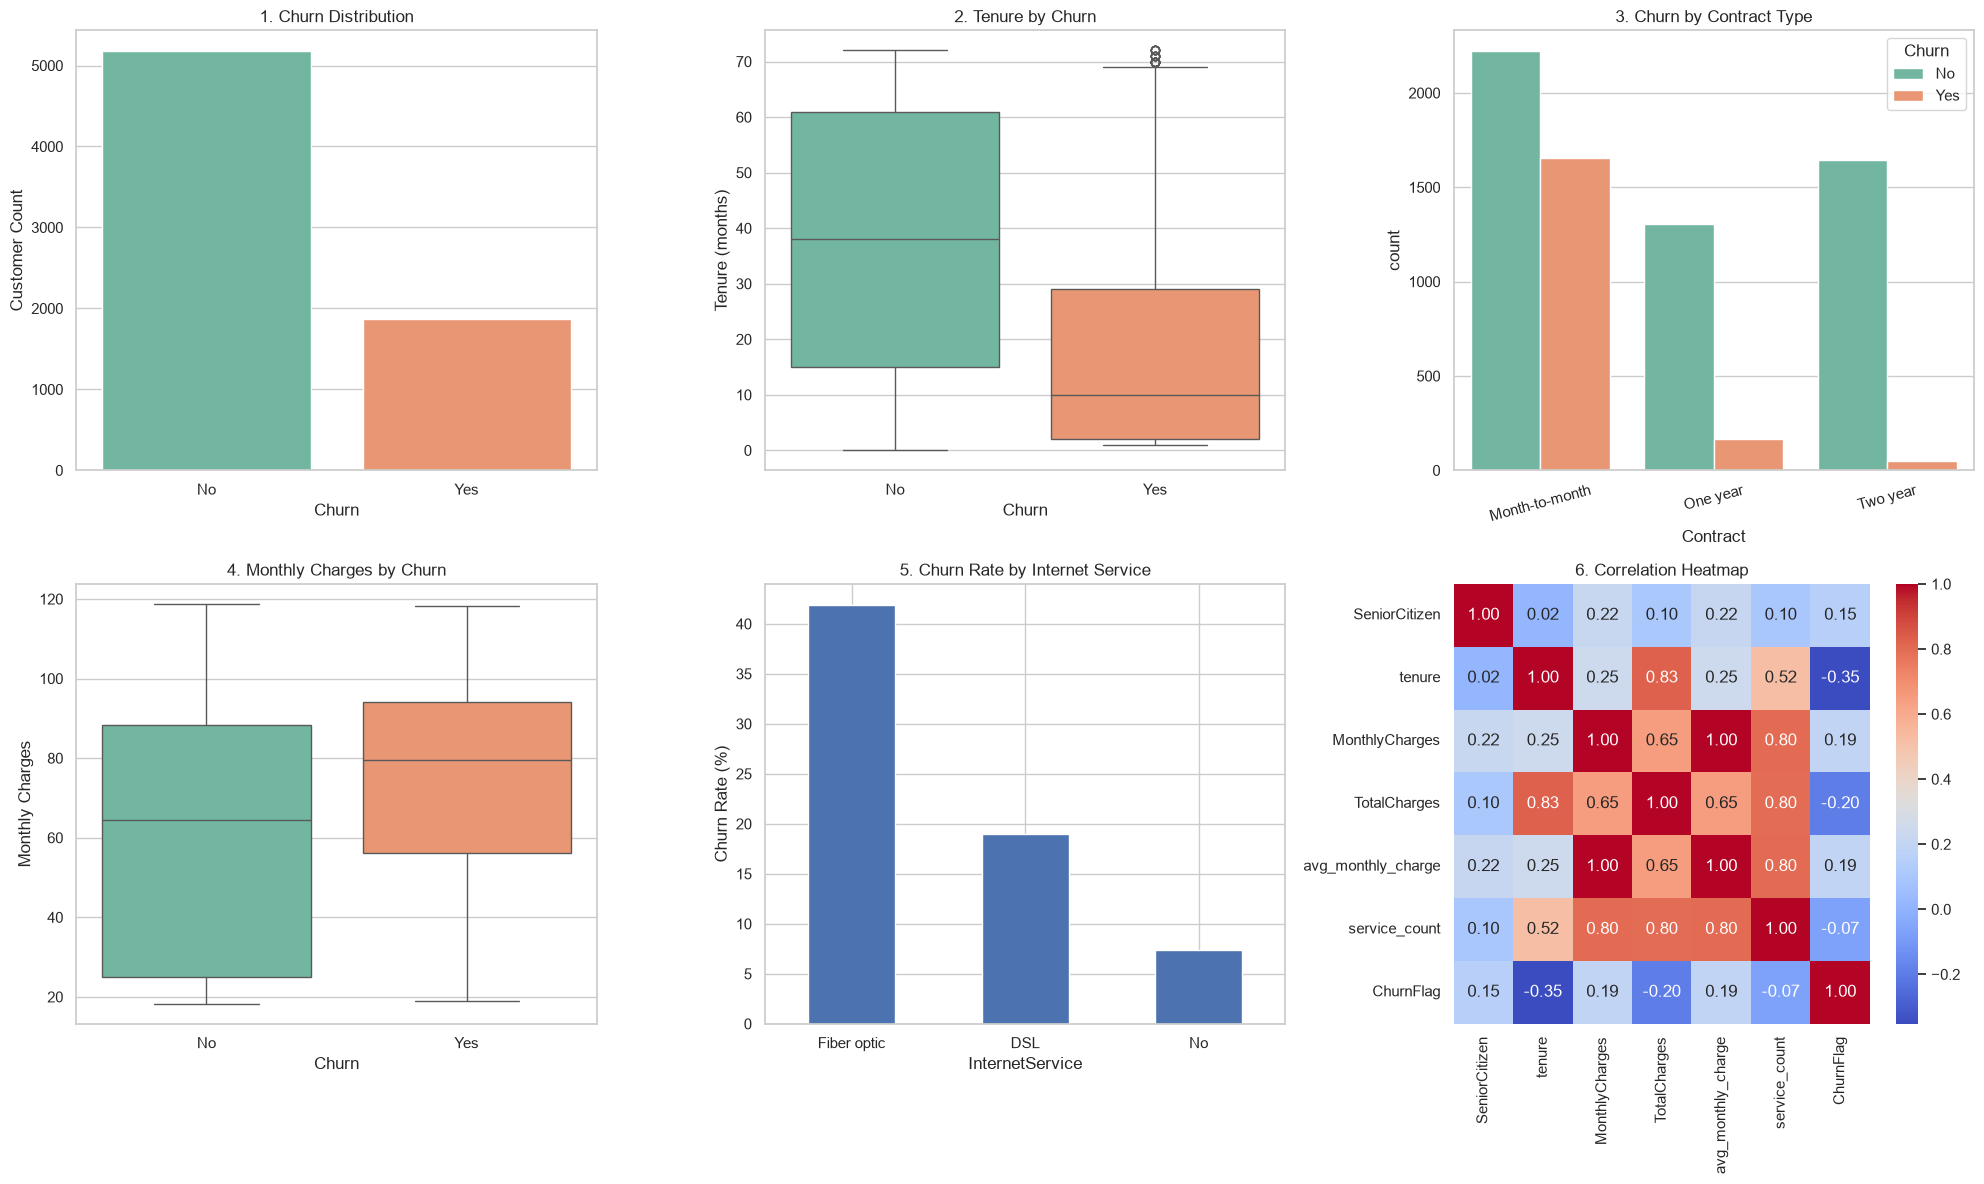

Business insights from EDA:
1. Churn distribution: 26.54% of customers churned, so churn is meaningful but not the majority class.
2. Tenure relationship: customers who churn have much lower median tenure (10.0 months) than retained customers (38.0 months).
3. Contract effect: the highest churn rate appears in Month-to-month contracts at 42.71%, suggesting contract commitment reduces churn.
4. Monthly charges: churned customers have a higher median monthly charge (79.65) than non-churned customers (64.43).
5. Internet service: Fiber optic customers show the highest churn rate at 41.89%, which points to service experience or pricing risk in that segment.
6. Correlation view: tenure and TotalCharges typically move together, while churn tends to increase with higher monthly charges and lower tenure.


In [19]:
eda_df = raw_df.copy()
eda_df["TotalCharges"] = pd.to_numeric(eda_df["TotalCharges"].replace(" ", np.nan), errors="coerce").fillna(0)
eda_df["ChurnFlag"] = eda_df["Churn"].map({"No": 0, "Yes": 1})

contract_churn = pd.crosstab(eda_df["Contract"], eda_df["Churn"], normalize="index") * 100
internet_churn = pd.crosstab(eda_df["InternetService"], eda_df["Churn"], normalize="index") * 100
corr_df = create_feature_table(raw_df[RAW_FEATURE_COLUMNS]).copy()
corr_df["ChurnFlag"] = eda_df["ChurnFlag"]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

sns.countplot(data=eda_df, x="Churn", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("1. Churn Distribution")
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Customer Count")

sns.boxplot(data=eda_df, x="Churn", y="tenure", palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title("2. Tenure by Churn")
axes[0, 1].set_xlabel("Churn")
axes[0, 1].set_ylabel("Tenure (months)")

sns.countplot(data=eda_df, x="Contract", hue="Churn", palette="Set2", ax=axes[0, 2])
axes[0, 2].set_title("3. Churn by Contract Type")
axes[0, 2].tick_params(axis="x", rotation=15)

sns.boxplot(data=eda_df, x="Churn", y="MonthlyCharges", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("4. Monthly Charges by Churn")
axes[1, 0].set_xlabel("Churn")
axes[1, 0].set_ylabel("Monthly Charges")

internet_churn["Yes"].sort_values(ascending=False).plot(kind="bar", color="#4C72B0", ax=axes[1, 1])
axes[1, 1].set_title("5. Churn Rate by Internet Service")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=0)

corr_matrix = corr_df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_charge", "service_count", "ChurnFlag"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 2])
axes[1, 2].set_title("6. Correlation Heatmap")

plt.tight_layout()
plt.show()

median_tenure = eda_df.groupby("Churn")["tenure"].median().to_dict()
median_monthly = eda_df.groupby("Churn")["MonthlyCharges"].median().round(2).to_dict()
contract_risk = contract_churn["Yes"].sort_values(ascending=False)
internet_risk = internet_churn["Yes"].sort_values(ascending=False)

print("Business insights from EDA:")
print(f"1. Churn distribution: {(eda_df['Churn'].eq('Yes').mean() * 100):.2f}% of customers churned, so churn is meaningful but not the majority class.")
print(f"2. Tenure relationship: customers who churn have much lower median tenure ({median_tenure['Yes']} months) than retained customers ({median_tenure['No']} months).")
print(f"3. Contract effect: the highest churn rate appears in {contract_risk.index[0]} contracts at {contract_risk.iloc[0]:.2f}%, suggesting contract commitment reduces churn.")
print(f"4. Monthly charges: churned customers have a higher median monthly charge ({median_monthly['Yes']}) than non-churned customers ({median_monthly['No']}).")
print(f"5. Internet service: {internet_risk.index[0]} customers show the highest churn rate at {internet_risk.iloc[0]:.2f}%, which points to service experience or pricing risk in that segment.")
print("6. Correlation view: tenure and TotalCharges typically move together, while churn tends to increase with higher monthly charges and lower tenure.")

## Section 3 - Feature Engineering

This section creates additional features that may help the model capture customer behavior patterns that are not obvious from the raw columns alone.

In [20]:
engineered_X = create_feature_table(X_raw)
feature_engineering_summary = pd.DataFrame([
    {
        "engineered_feature": "tenure_group",
        "how_it_was_created": "Binned tenure into 0-12, 13-24, 25-48, and 49-72 month ranges.",
        "why_it_is_useful": "Helps the model capture lifecycle stages such as new, growing, and long-term customers."
    },
    {
        "engineered_feature": "avg_monthly_charge",
        "how_it_was_created": "Calculated as TotalCharges divided by tenure, and set to MonthlyCharges when tenure is 0.",
        "why_it_is_useful": "Provides a normalized spending signal and makes new customers comparable with long-tenure customers."
    },
    {
        "engineered_feature": "service_count",
        "how_it_was_created": "Counted how many optional services the customer currently uses based on Yes values across service columns.",
        "why_it_is_useful": "Captures product depth and overall engagement, which may influence retention risk."
    },
])

display(feature_engineering_summary)
display(engineered_X[["tenure", "TotalCharges", "tenure_group", "avg_monthly_charge", "service_count"]].head(10))

feature_churn_view = engineered_X.copy()
feature_churn_view["Churn"] = y.values

tenure_group_churn = (feature_churn_view.groupby("tenure_group")["Churn"]
                      .apply(lambda s: (s == "Yes").mean())
                      .reset_index(name="churn_rate"))
tenure_group_churn["churn_rate"] = (tenure_group_churn["churn_rate"] * 100).round(2)
display(tenure_group_churn)

service_count_churn = (feature_churn_view.groupby("service_count")["Churn"]
                       .apply(lambda s: (s == "Yes").mean())
                       .reset_index(name="churn_rate"))
service_count_churn["churn_rate"] = (service_count_churn["churn_rate"] * 100).round(2)
display(service_count_churn)

,engineered_feature,how_it_was_created,why_it_is_useful
0,tenure_group,"Binned tenure into 0-12, 13-24, 25-48, and 49-...",Helps the model capture lifecycle stages such ...
1,avg_monthly_charge,"Calculated as TotalCharges divided by tenure, ...",Provides a normalized spending signal and make...
2,service_count,Counted how many optional services the custome...,"Captures product depth and overall engagement,..."


,tenure,TotalCharges,tenure_group,avg_monthly_charge,service_count
0,1,29.85,0-12 months,29.850000,1
1,34,1889.50,25-48 months,55.573529,3
2,2,108.15,0-12 months,54.075000,3
3,45,1840.75,25-48 months,40.905556,3
4,2,151.65,0-12 months,75.825000,1
5,8,820.50,0-12 months,102.562500,5
6,22,1949.40,13-24 months,88.609091,4
7,10,301.90,0-12 months,30.190000,1
8,28,3046.05,25-48 months,108.787500,6
9,62,3487.95,49-72 months,56.257258,3


,tenure_group,churn_rate
0,0-12 months,47.44
1,13-24 months,28.71
2,25-48 months,20.39
3,49-72 months,9.51


,service_count,churn_rate
0,0,43.75
1,1,21.11
2,2,32.83
3,3,36.48
4,4,31.34
5,5,25.55
6,6,22.49
7,7,12.41
8,8,5.29


## Section 4 - Model Development

A Decision Tree Classifier is trained with multiple configurations. The comparison focuses on test-set performance while preserving a leakage-safe preprocessing pipeline.

In [21]:
model_configs = [
    {"model_name": "tree_depth_3_gini", "max_depth": 3, "criterion": "gini"},
    {"model_name": "tree_depth_5_entropy", "max_depth": 5, "criterion": "entropy"},
    {"model_name": "tree_depth_8_gini", "max_depth": 8, "criterion": "gini"},
]

trained_models = {}
model_results = []

for config in model_configs:
    pipeline = build_pipeline(max_depth=config["max_depth"], criterion=config["criterion"])
    pipeline.fit(X_train_raw, y_train)

    predictions = pipeline.predict(X_test_raw)
    model_results.append({
        "model_name": config["model_name"],
        "criterion": config["criterion"],
        "max_depth": config["max_depth"],
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, pos_label="Yes"),
        "recall": recall_score(y_test, predictions, pos_label="Yes"),
        "f1_score": f1_score(y_test, predictions, pos_label="Yes"),
    })
    trained_models[config["model_name"]] = pipeline

model_results_df = pd.DataFrame(model_results).sort_values(
    by=["f1_score", "recall", "precision"], ascending=False
).reset_index(drop=True)
display(model_results_df.round(4))

best_model_name = model_results_df.loc[0, "model_name"]
final_model = trained_models[best_model_name]
final_config = next(config for config in model_configs if config["model_name"] == best_model_name)

print(f"Selected final model: {best_model_name}")
print(
    f"Reason: it achieved the best ranking on F1 score, then recall, then precision. "
    f"Final configuration -> criterion={final_config['criterion']}, max_depth={final_config['max_depth']}."
)

,model_name,criterion,max_depth,accuracy,precision,recall,f1_score
0,tree_depth_5_entropy,entropy,5,0.7932,0.6127,0.6007,0.6067
1,tree_depth_8_gini,gini,8,0.7766,0.5899,0.5205,0.5530
2,tree_depth_3_gini,gini,3,0.7875,0.6918,0.3601,0.4736


Selected final model: tree_depth_5_entropy
Reason: it achieved the best ranking on F1 score, then recall, then precision. Final configuration -> criterion=entropy, max_depth=5.


## Section 5 - Model Evaluation

The selected Decision Tree is evaluated with accuracy, precision, recall, F1 score, and a confusion matrix. The interpretation also explains which metric matters most in a churn use case.

,metric,value
0,Accuracy,0.7932
1,Precision,0.6127
2,Recall,0.6007
3,F1 Score,0.6067


,precision,recall,f1-score,support
No,0.8567,0.8628,0.8597,1552.0000
Yes,0.6127,0.6007,0.6067,561.0000
accuracy,0.7932,0.7932,0.7932,0.7932
macro avg,0.7347,0.7317,0.7332,2113.0000
weighted avg,0.7919,0.7932,0.7925,2113.0000


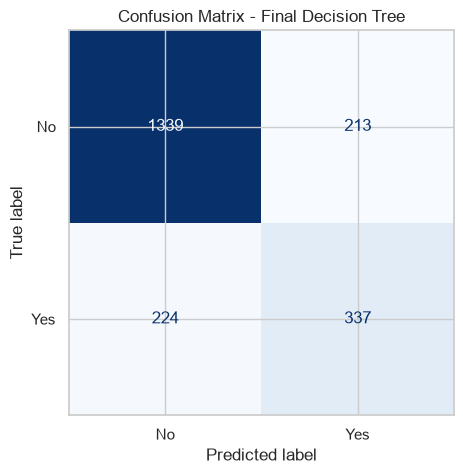

Business interpretation:
* Accuracy shows the model correctly classifies 79.32% of customers overall.
* Precision indicates how many customers flagged as churners truly churn. Higher precision means retention offers are spent more efficiently.
* Recall indicates how many real churners are successfully identified. Higher recall means fewer at-risk customers are missed.
* F1 Score balances precision and recall, which is helpful because churn interventions need both coverage and efficiency.
* For telecom churn, recall is usually the more important metric because missing a true churner means losing a customer and future revenue. A false positive still costs money, but it often only triggers a retention offer or outreach.


In [22]:
final_predictions = final_model.predict(X_test_raw)
final_probabilities = final_model.predict_proba(X_test_raw)
class_labels = list(final_model.named_steps["model"].classes_)
churn_class_index = class_labels.index("Yes")
churn_probabilities = final_probabilities[:, churn_class_index]

final_metrics = pd.DataFrame([
    {"metric": "Accuracy", "value": accuracy_score(y_test, final_predictions)},
    {"metric": "Precision", "value": precision_score(y_test, final_predictions, pos_label="Yes")},
    {"metric": "Recall", "value": recall_score(y_test, final_predictions, pos_label="Yes")},
    {"metric": "F1 Score", "value": f1_score(y_test, final_predictions, pos_label="Yes")},
])
display(final_metrics.round(4))

report_df = pd.DataFrame(classification_report(y_test, final_predictions, output_dict=True)).transpose()
display(report_df.round(4))

cm = confusion_matrix(y_test, final_predictions, labels=["No", "Yes"])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Final Decision Tree")
plt.show()

print("Business interpretation:")
print(f"* Accuracy shows the model correctly classifies {accuracy_score(y_test, final_predictions) * 100:.2f}% of customers overall.")
print(f"* Precision indicates how many customers flagged as churners truly churn. Higher precision means retention offers are spent more efficiently.")
print(f"* Recall indicates how many real churners are successfully identified. Higher recall means fewer at-risk customers are missed.")
print(f"* F1 Score balances precision and recall, which is helpful because churn interventions need both coverage and efficiency.")
print("* For telecom churn, recall is usually the more important metric because missing a true churner means losing a customer and future revenue. A false positive still costs money, but it often only triggers a retention offer or outreach.")

## Section 6 - Model Interpretation

This section explains what drives the model predictions by showing feature importance and the learned tree structure.

,feature,importance
0,cat__Contract_Month-to-month,0.526424
1,num__tenure,0.141690
2,cat__InternetService_Fiber optic,0.114063
3,num__MonthlyCharges,0.048724
4,num__TotalCharges,0.043512
5,num__avg_monthly_charge,0.029493
6,cat__OnlineSecurity_No,0.026400
7,cat__TechSupport_No,0.023462
8,cat__StreamingMovies_No internet service,0.013616
9,cat__PaymentMethod_Electronic check,0.012546


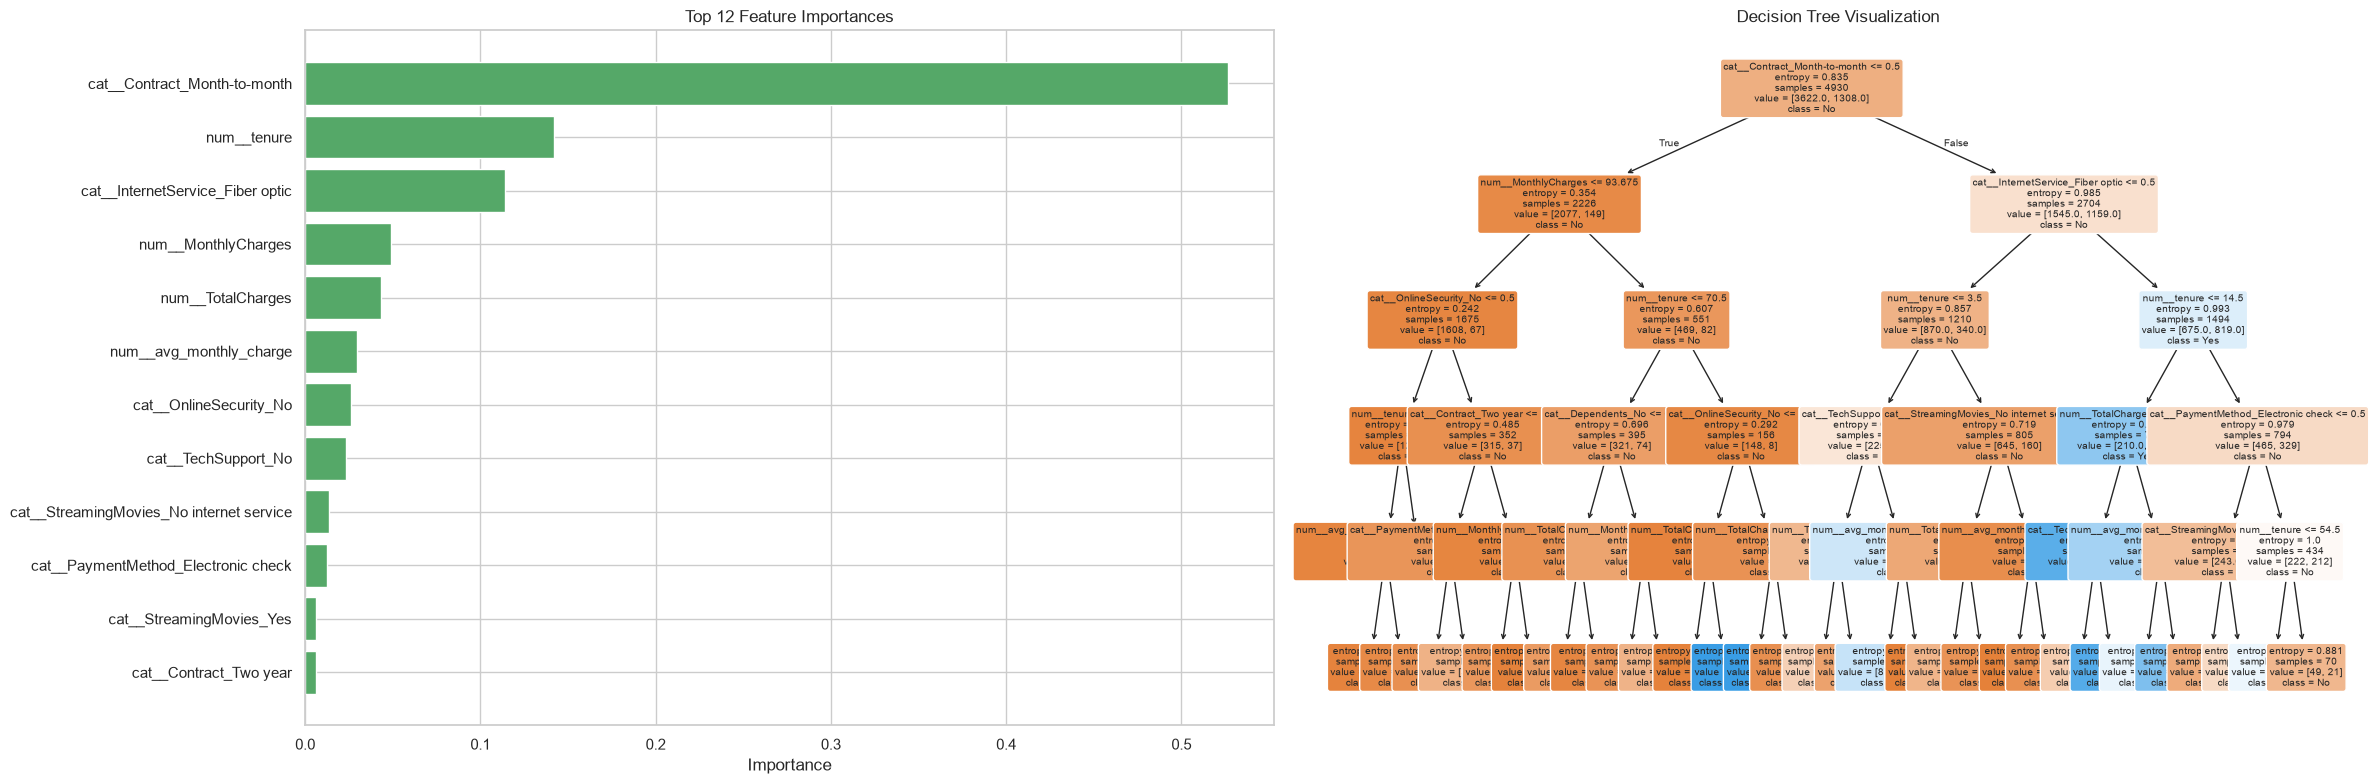

Key interpretation findings:
* cat__Contract_Month-to-month
* num__tenure
* cat__InternetService_Fiber optic
* num__MonthlyCharges
* num__TotalCharges
These top-ranked features indicate that pricing, tenure, service mix, and contract structure are central to churn risk in this dataset.


In [23]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
feature_importances = final_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances,
}).sort_values("importance", ascending=False)

display(importance_df.head(15).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

top_importance = importance_df.head(12).sort_values("importance")
axes[0].barh(top_importance["feature"], top_importance["importance"], color="#55A868")
axes[0].set_title("Top 12 Feature Importances")
axes[0].set_xlabel("Importance")

plot_tree(
    final_model.named_steps["model"],
    feature_names=feature_names,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=axes[1],
)
axes[1].set_title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

print("Key interpretation findings:")
for feature in importance_df.head(5)["feature"].tolist():
    print(f"* {feature}")
print("These top-ranked features indicate that pricing, tenure, service mix, and contract structure are central to churn risk in this dataset.")

## Additional Improvements

This section demonstrates hyperparameter tuning with GridSearchCV, class imbalance handling with `class_weight='balanced'`, and a comparison of multiple classification algorithms beyond Decision Trees.

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Build a base pipeline for grid search
base_pipeline = build_pipeline(max_depth=None, criterion="gini")

param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__criterion": ["gini", "entropy"],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

# Use a custom scorer because our labels are "Yes"/"No", not 1/0
f1_yes_scorer = make_scorer(f1_score, pos_label="Yes")

grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    cv=5,
    scoring=f1_yes_scorer,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

grid_search.fit(X_train_raw, y_train)

print("Best hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 score: {grid_search.best_score_:.4f}")

tuned_predictions = grid_search.predict(X_test_raw)
tuned_metrics = pd.DataFrame([{
    "metric": "Accuracy", "tuned_value": accuracy_score(y_test, tuned_predictions),
}, {
    "metric": "Precision", "tuned_value": precision_score(y_test, tuned_predictions, pos_label="Yes"),
}, {
    "metric": "Recall", "tuned_value": recall_score(y_test, tuned_predictions, pos_label="Yes"),
}, {
    "metric": "F1 Score", "tuned_value": f1_score(y_test, tuned_predictions, pos_label="Yes"),
}])
display(tuned_metrics.round(4))
print("Hyperparameter tuning explores a broader search space than the manual configurations in Section 4 and often finds a better balance between precision and recall.")

Best hyperparameters:
  model__criterion: gini
  model__max_depth: 5
  model__min_samples_leaf: 4
  model__min_samples_split: 2

Best CV F1 score: 0.5722


,metric,tuned_value
0,Accuracy,0.7937
1,Precision,0.6138
2,Recall,0.6007
3,F1 Score,0.6072


Hyperparameter tuning explores a broader search space than the manual configurations in Section 4 and often finds a better balance between precision and recall.


In [25]:
# Retrain the best grid-search configuration but add class_weight='balanced'
# to penalize misclassifying the minority class (Churn=Yes) more heavily.
best_params = grid_search.best_params_
balanced_pipeline = build_pipeline(
    max_depth=best_params.get("model__max_depth"),
    criterion=best_params.get("model__criterion", "gini"),
)
balanced_pipeline.named_steps["model"].set_params(
    class_weight="balanced",
    min_samples_split=best_params.get("model__min_samples_split", 2),
    min_samples_leaf=best_params.get("model__min_samples_leaf", 1),
)
balanced_pipeline.fit(X_train_raw, y_train)

bal_preds = balanced_pipeline.predict(X_test_raw)

comparison = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "original_tree": [
        accuracy_score(y_test, final_predictions),
        precision_score(y_test, final_predictions, pos_label="Yes"),
        recall_score(y_test, final_predictions, pos_label="Yes"),
        f1_score(y_test, final_predictions, pos_label="Yes"),
    ],
    "tuned_tree": [
        accuracy_score(y_test, tuned_predictions),
        precision_score(y_test, tuned_predictions, pos_label="Yes"),
        recall_score(y_test, tuned_predictions, pos_label="Yes"),
        f1_score(y_test, tuned_predictions, pos_label="Yes"),
    ],
    "balanced_tree": [
        accuracy_score(y_test, bal_preds),
        precision_score(y_test, bal_preds, pos_label="Yes"),
        recall_score(y_test, bal_preds, pos_label="Yes"),
        f1_score(y_test, bal_preds, pos_label="Yes"),
    ],
})
display(comparison.round(4))

print("Using class_weight='balanced' typically increases recall at the expense of precision.")
print("For churn prediction, this trade-off is usually favorable because missing a churner is more costly than a false alarm.")

,metric,original_tree,tuned_tree,balanced_tree
0,Accuracy,0.7932,0.7937,0.6976
1,Precision,0.6127,0.6138,0.4615
2,Recall,0.6007,0.6007,0.8342
3,F1 Score,0.6067,0.6072,0.5943


Using class_weight='balanced' typically increases recall at the expense of precision.
For churn prediction, this trade-off is usually favorable because missing a churner is more costly than a false alarm.


,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.7591,0.5332,0.7451,0.6216,0.8363
1,Logistic Regression,0.7416,0.5086,0.7950,0.6203,0.8441
2,Decision Tree (tuned),0.7937,0.6138,0.6007,0.6072,0.8275
3,Balanced Decision Tree,0.6976,0.4615,0.8342,0.5943,0.8288
4,Gradient Boosting,0.7903,0.6347,0.4955,0.5566,0.8321


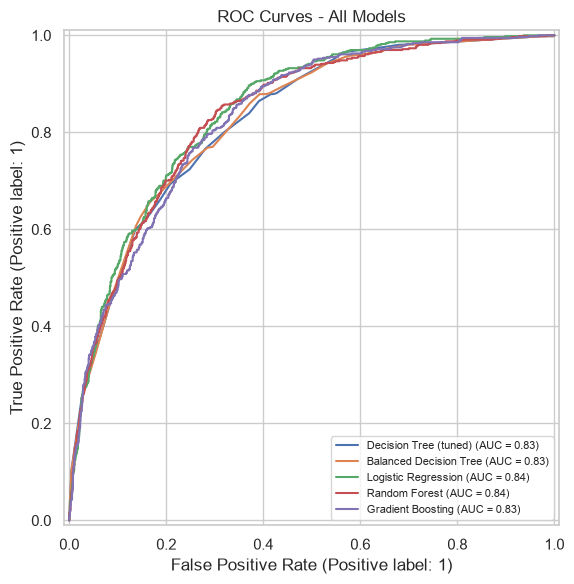

Best overall model: Random Forest with F1=0.6216 and ROC-AUC=0.8363
Ensemble methods like Random Forest and Gradient Boosting typically outperform a single Decision Tree by reducing variance and capturing more complex feature interactions.

The best model (Random Forest) will be saved as the final model for deployment.


In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Define alternative models using the same preprocessing pipeline structure
alternative_models = {
    "Decision Tree (tuned)": grid_search.best_estimator_,
    "Balanced Decision Tree": balanced_pipeline,
}

# Build fresh pipelines for the new algorithms
for name, model_cls, params in [
    ("Logistic Regression", LogisticRegression, {"max_iter": 1000, "random_state": RANDOM_STATE, "class_weight": "balanced"}),
    ("Random Forest", RandomForestClassifier, {"n_estimators": 100, "max_depth": 10, "random_state": RANDOM_STATE, "class_weight": "balanced", "n_jobs": -1}),
    ("Gradient Boosting", GradientBoostingClassifier, {"n_estimators": 100, "max_depth": 5, "random_state": RANDOM_STATE, "learning_rate": 0.1}),
]:
    pipe = build_pipeline()  # uses default DT, we replace model step
    pipe.set_params(model=model_cls(**params))
    pipe.fit(X_train_raw, y_train)
    alternative_models[name] = pipe

# Evaluate all models
all_model_results = []
for name, pipe in alternative_models.items():
    preds = pipe.predict(X_test_raw)
    proba = pipe.predict_proba(X_test_raw)
    classes = list(pipe.named_steps["model"].classes_)
    churn_idx = classes.index("Yes")
    all_model_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, pos_label="Yes"),
        "recall": recall_score(y_test, preds, pos_label="Yes"),
        "f1_score": f1_score(y_test, preds, pos_label="Yes"),
        "roc_auc": roc_auc_score((y_test == "Yes").astype(int), proba[:, churn_idx]),
    })

all_results_df = pd.DataFrame(all_model_results).sort_values("f1_score", ascending=False).reset_index(drop=True)
display(all_results_df.round(4))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in alternative_models.items():
    classes = list(pipe.named_steps["model"].classes_)
    churn_idx = classes.index("Yes")
    proba = pipe.predict_proba(X_test_raw)[:, churn_idx]
    RocCurveDisplay.from_predictions(
        (y_test == "Yes").astype(int), proba, name=name, ax=ax
    )
ax.set_title("ROC Curves - All Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

best_overall = all_results_df.iloc[0]
best_overall_name = best_overall["model"]
best_overall_model = alternative_models[best_overall_name]

print(f"Best overall model: {best_overall_name} with F1={best_overall['f1_score']:.4f} and ROC-AUC={best_overall['roc_auc']:.4f}")
print("Ensemble methods like Random Forest and Gradient Boosting typically outperform a single Decision Tree by reducing variance and capturing more complex feature interactions.")
print(f"\nThe best model ({best_overall_name}) will be saved as the final model for deployment.")

# Promote best model to final_model so downstream cells (save, API) use it
final_model = best_overall_model

Feature importance for the best model: Random Forest


,feature,importance
0,cat__Contract_Month-to-month,0.132006
1,num__TotalCharges,0.090075
2,num__tenure,0.086510
3,num__avg_monthly_charge,0.068003
4,num__MonthlyCharges,0.064897
5,cat__OnlineSecurity_No,0.050619
6,cat__InternetService_Fiber optic,0.037003
7,cat__TechSupport_No,0.034760
8,cat__tenure_group_0-12 months,0.034147
9,cat__PaymentMethod_Electronic check,0.033647


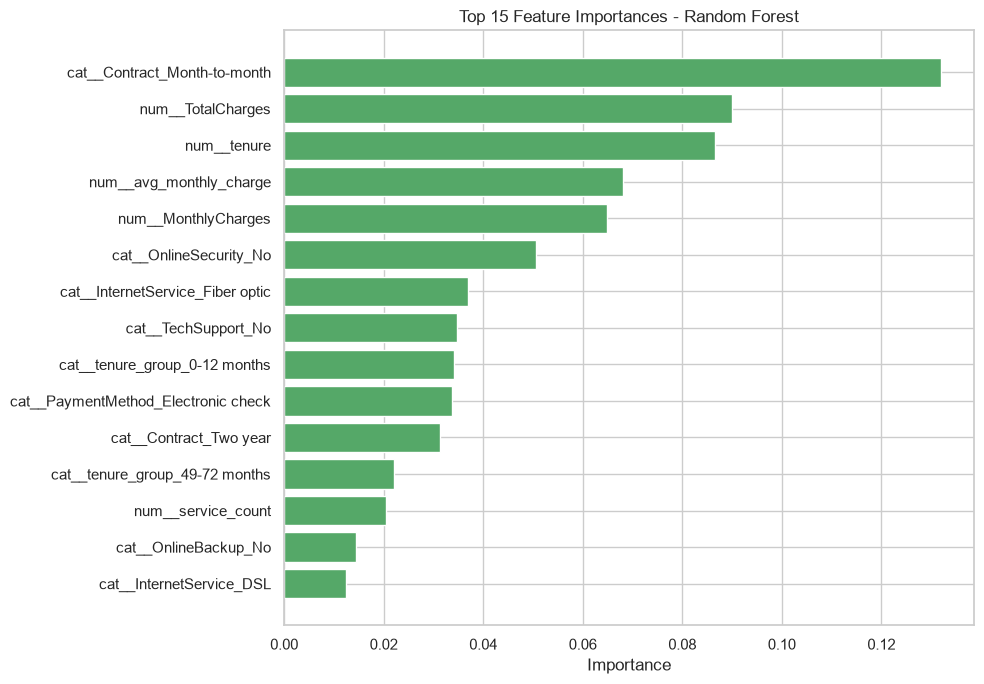


Key interpretation findings for Random Forest:
  * cat__Contract_Month-to-month
  * num__TotalCharges
  * num__tenure
  * num__avg_monthly_charge
  * num__MonthlyCharges

Compared to the base Decision Tree (Section 6), the Random Forest redistributes
importance more evenly across features, reflecting its ability to capture richer interactions.


In [27]:
# Interpret the best overall model from the bonus comparison
best_feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
best_importances = final_model.named_steps["model"].feature_importances_

best_importance_df = pd.DataFrame({
    "feature": best_feature_names,
    "importance": best_importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Feature importance for the best model: {best_overall_name}")
display(best_importance_df.head(15))

fig, ax = plt.subplots(figsize=(10, 7))
top_features = best_importance_df.head(15).sort_values("importance")
ax.barh(top_features["feature"], top_features["importance"], color="#55A868")
ax.set_title(f"Top 15 Feature Importances - {best_overall_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"\nKey interpretation findings for {best_overall_name}:")
for feat in best_importance_df.head(5)["feature"].tolist():
    print(f"  * {feat}")
print(f"\nCompared to the base Decision Tree (Section 6), the {best_overall_name} redistributes")
print("importance more evenly across features, reflecting its ability to capture richer interactions.")

## Section 7 - Model Saving and API Artifacts

The final model is saved to a local `model/` directory. The next cells generate the FastAPI application, requirements file, sample request, and README content.

In [28]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, MODEL_PATH)

sample_customer = X_test_raw.iloc[0].to_dict()
serializable_sample_customer = {
    key: (
        int(value) if isinstance(value, (np.integer,)) else
        float(value) if isinstance(value, (np.floating,)) else
        value
    )
    for key, value in sample_customer.items()
}

sample_prediction = final_model.predict(pd.DataFrame([sample_customer]))[0]
sample_probability = float(final_model.predict_proba(pd.DataFrame([sample_customer]))[0][churn_class_index])

artifact_summary = pd.DataFrame([
    {"artifact": "model", "value": str(MODEL_PATH)},
    {"artifact": "sample prediction label", "value": str(sample_prediction)},
    {"artifact": "sample churn probability", "value": str(round(sample_probability, 4))},
])
display(artifact_summary)
print(f"Model saved successfully to: {MODEL_PATH}")

,artifact,value
0,model,C:\Users\chagantychaitanya\Downloads\nagp_ml\m...
1,sample prediction label,Yes
2,sample churn probability,0.7944


Model saved successfully to: C:\Users\chagantychaitanya\Downloads\nagp_ml\model\churn_model.pkl
